# Losing the Ball: Where It Costs, and Whether Pressing Helps

**Analytics Cup 2.0 — Football, Defensive Positioning**

[Notebook 06](06_counter_attack_dataset.ipynb) built the 296 counter-attacks and found two walls:
only 15 of them end in a goal (far too few to learn defensive routes from), and three independent
danger measures — a pitch-control prototype, SkillCorner's own EPV, and a "reachable but absent
defender" error count — could not predict a counter's outcome better than *where the ball was*.
Once a counter is running, its outcome is close to unpredictable from positions.

That points one step earlier: **the moment the ball is lost**. This notebook moves the unit of
analysis from 296 counters to every open-play turnover (2,435) and asks two coaching questions:

1. **Where does losing the ball cost the most?** (shot/goal conceded soon after, by pitch zone)
2. **When you lose it, does pressing immediately help** — and who presses?

Tactical framing throughout comes from the project author's reading of the game: good teams stay
compact to have numerical superiority *when* they lose the ball, press in the rival half, and sit
in a compact low block in their own half, where at most the nearest player steps out.


## 1. The turnover dataset

Built by [`src/turnovers.py`](../src/turnovers.py) and cached (gitignored) under `data/processed/`. A turnover starts from a possession ending in `possession_loss` or an unsuccessful pass. Coordinates are rotated so **the team that lost the ball always attacks towards +x** — its own goal is at x = −52.5.

In [1]:
import sys
sys.path.insert(0, "../src")
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint
from mplsoccer import Pitch

from turnovers import (load_or_build_turnovers, compute_turnover_outcomes, player_reactions,
                       players_near_ball, load_player_roles)
from defensive_features import build_team_defensive_features, load_match_meta

pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"] = 110
DATA_DIR = "../../skillcorner-opendata/data/matches"
turnovers, traj = load_or_build_turnovers(DATA_DIR, "../data/processed")
print(f"turnovers: {len(turnovers)} | trajectory rows (-1 s to +5 s around each loss): {len(traj):,}")
turnovers.groupby(["rival_controlled", "loss_type"]).size().rename("n").to_frame()


turnovers: 2435 | trajectory rows (-1 s to +5 s around each loss): 3,414,810


n
rival_controlled loss_type            
False            misplaced_pass    211
                 possession_loss   185
True             misplaced_pass   1350
                 possession_loss   689

### Which candidate losses are kept, and why

A loss event is not automatically a change of possession. Every candidate is accounted for:

* **Rival controls the ball within 3 s** → kept (`rival_controlled=True`). The moment/place of the
  loss is the rival's *first controlled possession*: for a misplaced pass, the event's own x/y is
  where the passer stood, not where the ball was won.
* **A teammate controls it next, within 5 s, and a rival got within 1.5 m of the ball in between**
  → kept as an *immediate contested recovery* (`rival_controlled=False`). These are often the most
  successful counter-presses, so leaving them out would bias everything towards failures.
* **A teammate controls it next with no rival ever near the ball** → dropped: an imprecise pass
  collected by a teammate was never a loss.
* **Longer gaps** (mostly ball out of play) → dropped: the defence had time to reorganise.

In [2]:
rows = []
for d in sorted(glob.glob(DATA_DIR + "/*")):
    mid = d.replace("\\", "/").split("/")[-1]
    ev = pd.read_csv(f"{d}/{mid}_dynamic_events.csv", low_memory=False,
                     usecols=["event_type", "end_type", "pass_outcome", "team_id", "frame_start", "frame_end", "period"])
    pp = ev[ev["event_type"] == "player_possession"].sort_values("frame_start").reset_index(drop=True)
    loss = (pp["end_type"] == "possession_loss") | ((pp["end_type"] == "pass") & (pp["pass_outcome"] == "unsuccessful"))
    for i in np.flatnonzero(loss.to_numpy()):
        if i + 1 >= len(pp) or pp.loc[i + 1, "period"] != pp.loc[i, "period"]:
            rows.append("end of period / no next possession"); continue
        gap = (pp.loc[i + 1, "frame_start"] - pp.loc[i, "frame_end"]) / 10
        if pp.loc[i + 1, "team_id"] != pp.loc[i, "team_id"]:
            rows.append("rival controls within 3 s" if gap <= 3 else "rival controls after >3 s (stoppage)")
        else:
            rows.append("teammate controls within 5 s" if gap <= 5 else "teammate controls after >5 s")
cand = pd.Series(rows).value_counts().rename("candidates").to_frame()
cand.loc["  -> of which contested (kept)", "candidates"] = int((~turnovers["rival_controlled"]).sum())
cand


,candidates
rival controls within 3 s,2039.0
rival controls after >3 s (stoppage),779.0
teammate controls within 5 s,636.0
teammate controls after >5 s,562.0
end of period / no next possession,20.0
-> of which contested (kept),396.0


## 2. Validation before any result

Three independent checks that the reconstruction is right, plus one that the goal flag used as an outcome is right.

In [3]:
gf = turnovers.set_index("turnover_id")["gain_frame"]
at_loss = traj[traj["frame"] == traj["turnover_id"].map(gf)]
ball = at_loss[at_loss["role"] == "ball"].set_index("turnover_id")[["x", "y"]]
chk = turnovers.set_index("turnover_id").join(ball)
rc = chk[chk["rival_controlled"]]
dist = np.hypot(rc["x"] - rc["loss_x"], rc["y"] - rc["loss_y"])
print(f"1) event loss location vs tracked ball (rival-controlled): median {dist.median():.2f} m, p90 {dist.quantile(.9):.2f} m")
gk = at_loss[(at_loss["role"] == "losing") & at_loss["is_goalkeeper"]]
print(f"2) losing team's goalkeeper at negative x (rotation correct): {(gk['x'] < 0).mean():.1%} of {len(gk)} losses")
n_players = at_loss[at_loss["role"] != "ball"].groupby("turnover_id").size()
print(f"3) players tracked at the loss frame: min {n_players.min()}, max {n_players.max()}")


1) event loss location vs tracked ball (rival-controlled): median 1.41 m, p90 2.82 m
2) losing team's goalkeeper at negative x (rotation correct): 100.0% of 2435 losses
3) players tracked at the loss frame: min 22, max 22


For the 396 contested recoveries, check 1 is meaningless (their location *is* the tracked ball),
so they get an independent check: the contest location vs the losing event's own end location in
the event data. They agree to a median of ~2 m, and the contest happens a median of ~0.1 s after
the loss (computed while building the dataset; see the module docstring).

In [4]:
import json
goals_flagged, goals_real = 0, 0
for d in sorted(glob.glob(DATA_DIR + "/*")):
    mid = d.replace("\\", "/").split("/")[-1]
    m = json.load(open(f"{d}/{mid}_match.json", encoding="utf-8"))
    goals_real += m["home_team_score"] + m["away_team_score"]
    ev = pd.read_csv(f"{d}/{mid}_dynamic_events.csv", low_memory=False, usecols=["event_type", "end_type", "lead_to_goal"])
    goals_flagged += int(((ev["event_type"] == "player_possession") & (ev["end_type"] == "shot") & (ev["lead_to_goal"] == True)).sum())
print(f"4) shots flagged lead_to_goal: {goals_flagged} vs goals in the real scorelines: {goals_real}")


4) shots flagged lead_to_goal: 64 vs goals in the real scorelines: 66


64 of 66: the two missing goals are not open-play shots by the scoring team (penalties/own goals). The goal flag is trustworthy.

## 3. Where does losing the ball cost the most?

**Outcome (primary):** the rival shoots within 15 s of the loss, before the losing team touches the
ball again. A goal scored after a minute of patient build-up isn't a consequence of the loss, so the
window is deliberately short. Goals are reported too, but there are only ~16 of them — **shots are
the reliable indicator, goals are indicative**. Every rate comes with a 95% Wilson interval.

In [5]:
outcomes = compute_turnover_outcomes(DATA_DIR, turnovers)
d = turnovers.merge(outcomes, on="turnover_id")
d["third"] = pd.cut(d["loss_x"], [-60, -17.5, 17.5, 60], labels=["own third", "middle third", "rival third"])
d["lane"] = np.where(d["loss_y"].abs() <= 20.16, "centre", "wings")  # centre lane = width of the penalty box

def rate(s):
    k, n = int(s.sum()), len(s)
    lo, hi = proportion_confint(k, n, method="wilson")
    return f"{k/n:5.1%} [{lo:4.1%}-{hi:4.1%}] ({k})"

print(f"shots conceded within 15 s: {d['shot_15s'].sum()} | goals: {d['goal_15s'].sum()} | regained within 5 s: {d['regained_5s'].mean():.1%}")
d.groupby("third", observed=True).agg(n=("turnover_id", "size"), shot_15s=("shot_15s", rate), goal_15s=("goal_15s", rate))


shots conceded within 15 s: 120 | goals: 16 | regained within 5 s: 39.5%


,n,shot_15s,goal_15s
third,,,
own third,380,12.1% [9.2%-15.8%] (46),1.6% [0.7%-3.4%] (6)
middle third,980,5.9% [4.6%-7.6%] (58),0.8% [0.4%-1.6%] (8)
rival third,1075,1.5% [0.9%-2.4%] (16),0.2% [0.1%-0.7%] (2)


In [6]:
d.groupby(["third", "lane"], observed=True).agg(n=("turnover_id", "size"), shot_15s=("shot_15s", rate), goal_15s=("goal_15s", rate))


n                  shot_15s               goal_15s
third        lane                                                        
own third    centre  199  14.6% [10.3%-20.1%] (29)   1.5% [0.5%-4.3%] (3)
             wings   181    9.4% [5.9%-14.5%] (17)   1.7% [0.6%-4.8%] (3)
middle third centre  556    7.7% [5.8%-10.3%] (43)   0.9% [0.4%-2.1%] (5)
             wings   424     3.5% [2.2%-5.8%] (15)   0.7% [0.2%-2.1%] (3)
rival third  centre  732      1.2% [0.6%-2.3%] (9)   0.1% [0.0%-0.8%] (1)
             wings   343      2.0% [1.0%-4.2%] (7)   0.3% [0.1%-1.6%] (1)

In [7]:
base = d.loc[d["third"] == "rival third", "shot_15s"].mean()
for t in ["own third", "middle third"]:
    print(f"{t}: {d.loc[d['third'] == t, 'shot_15s'].mean() / base:.1f}x the shot risk of losing it in the rival third")
print()
print("Sensitivity - same map without the 396 immediate contested recoveries:")
pd.DataFrame({
    "all turnovers": d.groupby("third", observed=True)["shot_15s"].apply(rate),
    "rival-controlled only": d[d["rival_controlled"]].groupby("third", observed=True)["shot_15s"].apply(rate),
})


own third: 8.1x the shot risk of losing it in the rival third
middle third: 4.0x the shot risk of losing it in the rival third

Sensitivity - same map without the 396 immediate contested recoveries:


,all turnovers,rival-controlled only
third,,
own third,12.1% [9.2%-15.8%] (46),15.9% [12.2%-20.6%] (46)
middle third,5.9% [4.6%-7.6%] (58),6.9% [5.4%-8.8%] (58)
rival third,1.5% [0.9%-2.4%] (16),1.8% [1.1%-2.8%] (16)


### The cost map

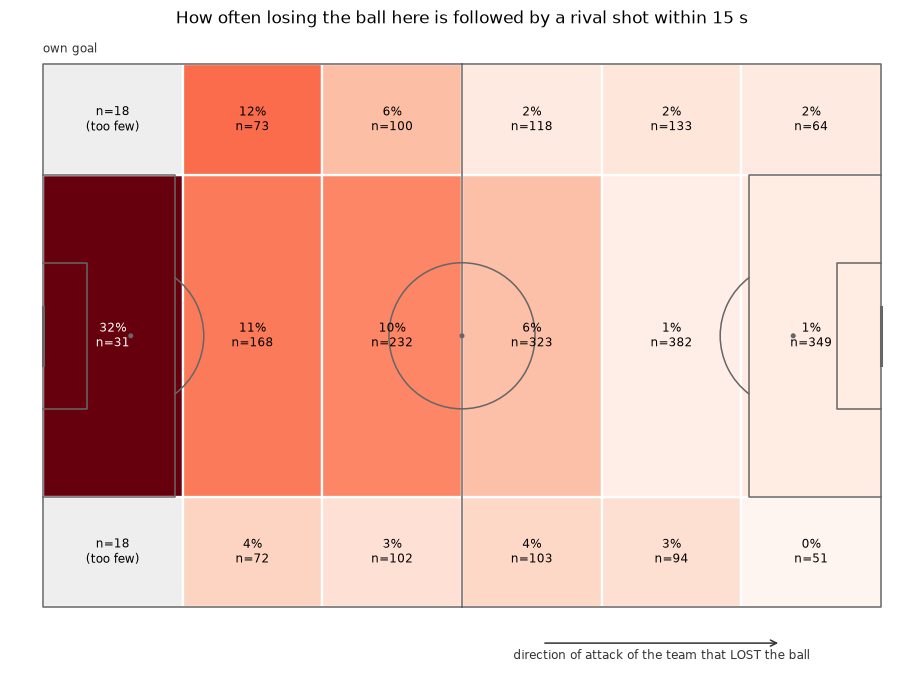

In [8]:
x_edges = np.linspace(-52.5, 52.5, 7)
y_edges = np.array([-34, -20.16, 20.16, 34])
pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#666666", linewidth=1, line_zorder=3)
fig, ax = pitch.draw(figsize=(10, 6.2))
cmap = plt.get_cmap("Reds")
vmax = 0.25
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        cell = d[(d["loss_x"] >= x_edges[i]) & (d["loss_x"] < x_edges[i + 1]) & (d["loss_y"] >= y_edges[j]) & (d["loss_y"] < y_edges[j + 1])]
        n = len(cell)
        r = cell["shot_15s"].mean() if n else np.nan
        colour = "#eeeeee" if n < 30 else cmap(min(r / vmax, 1.0))
        ax.add_patch(plt.Rectangle((x_edges[i], y_edges[j]), x_edges[i + 1] - x_edges[i], y_edges[j + 1] - y_edges[j],
                                   facecolor=colour, edgecolor="white", linewidth=1.5, zorder=1))
        label = f"{r:.0%}\nn={n}" if n >= 30 else f"n={n}\n(too few)"
        txt_colour = "white" if n >= 30 and r / vmax > 0.6 else "black"
        ax.text((x_edges[i] + x_edges[i + 1]) / 2, (y_edges[j] + y_edges[j + 1]) / 2, label, ha="center", va="center", fontsize=8, zorder=4, color=txt_colour)
ax.annotate("", xy=(40, -38.5), xytext=(10, -38.5), arrowprops=dict(arrowstyle="->", color="#333333"), annotation_clip=False)
ax.text(25, -40.5, "direction of attack of the team that LOST the ball", ha="center", fontsize=8, color="#333333")
ax.text(-52.5, 35.5, "own goal", fontsize=8, color="#333333")
ax.set_title("How often losing the ball here is followed by a rival shot within 15 s", fontsize=11)
plt.show()


**What the map says**

* **Losing it in your own third is ~8× as costly** (in shots conceded) as losing it in the rival
  third (~9× counting only rival-controlled losses); the middle third ~4×. The confidence intervals
  of the three thirds don't overlap. In the cell that contains your own box it is ~1 in 3 (only n=31, so wide uncertainty).
* **In your own half, the centre costs more than the wings**: ~15% vs ~9% in the own third, ~8% vs
  ~3.5% in the middle third. In the rival third the ordering flips, but with so few shots that
  difference isn't reliable.
* **Losing it high is almost free** (~1.5–2% shot within 15 s). This is the quantitative case for a
  high, compact team: it can afford to lose the ball where it mostly loses it.
* The map holds with or without the immediate contested recoveries — the conclusion doesn't depend
  on how those are weighted.

### A left/right asymmetry — spotted, not searched for

The map shows the own-half **left** flank (top) far costlier than the right (bottom). Two checks
before taking it seriously: (1) is "left" really the losing team's left? (2) is it more than noise?

In [9]:
a = traj[np.isclose(traj["t"], 0) & (traj["role"] == "losing")].merge(turnovers[["turnover_id", "match_id"]], on="turnover_id")
a = a.merge(load_player_roles(DATA_DIR), on=["match_id", "player_id"])
side_roles = a[a["role_name"].isin(["Left Back", "Left Winger", "Left Center Back", "Right Back", "Right Winger", "Right Center Back"])]
print("orientation check - mean y at the loss (left roles should be positive):")
print(side_roles.groupby("role_name")["y"].mean().round(1).to_string())

from scipy.stats import fisher_exact
fl = d[(d["loss_x"] < 0) & (d["loss_y"].abs() > 20.16)].copy()
fl["flank"] = np.where(fl["loss_y"] > 0, "left flank", "right flank")
t = pd.crosstab(fl["flank"], fl["shot_15s"])
print()
print(t)
print(f"shot rate: left {fl.loc[fl['flank'] == 'left flank', 'shot_15s'].mean():.1%} vs right {fl.loc[fl['flank'] == 'right flank', 'shot_15s'].mean():.1%} | Fisher exact p = {fisher_exact(t.values)[1]:.3f}")
_, _, names = load_match_meta(DATA_DIR)
print("teams conceding those shots:", fl[fl["shot_15s"]].assign(team=lambda x: x["losing_team_id"].map(names)).groupby("flank")["team"].nunique().to_dict())


orientation check - mean y at the loss (left roles should be positive):
role_name
Left Back            17.3
Left Center Back      7.2
Left Winger          11.1
Right Back          -15.2
Right Center Back    -6.4
Right Winger        -10.1



shot_15s     False  True 
flank                    
left flank     172     19
right flank    185      7
shot rate: left 9.9% vs right 3.6% | Fisher exact p = 0.015


teams conceding those shots: {'left flank': 10, 'right flank': 6}


Orientation is right (left-sided roles sit at positive y), and the gap isn't one team's doing —
the left-flank shots are spread across ten teams. But this comparison was **noticed in a figure with
18 cells, not planned**, so p=0.015 overstates the evidence: with that many implicit comparisons, a
gap this size can appear by chance. It is carried forward as a **hypothesis** to be explained (and
tested on its own mechanism) in the next notebook, not as a finding.

## 4. Measuring who presses — a failed first version, and the fix

After each loss, each outfield player of the losing team is labelled over the first **2 s**:
**press**, **retreat** (≥3 m towards his own goal) or **hold**. The first definition of *press* —
"his distance to the ball shrank by ≥3 m, or he ended within 3 m" — looked reasonable and was wrong.
It is shown here because the way it failed is itself a lesson about this data.

In [10]:
pl = player_reactions(traj)
roles = load_player_roles(DATA_DIR)
pl = pl.merge(turnovers[["turnover_id", "match_id", "gain_frame", "loss_x", "losing_team_id"]], on="turnover_id")
pl = pl.merge(roles[["match_id", "player_id", "position_group"]], on=["match_id", "player_id"], how="left")

# v1 (wrong): distance to the ball shrank
v1_press = ((pl["d0"] - pl["dH"]) >= 3) | (pl["dH"] <= 3)
pl["action_v1"] = np.select([v1_press, ~v1_press & (pl["dx"] <= -3)], ["press", "retreat"], "hold")

# reference: SkillCorner's own on_ball_engagement events for the same player in the same 2 s
eng = []
for mid in turnovers["match_id"].unique():
    ev = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_dynamic_events.csv", low_memory=False, usecols=["event_type", "player_id", "frame_start"])
    e = ev[ev["event_type"] == "on_ball_engagement"][["player_id", "frame_start"]].copy()
    e["match_id"] = mid
    eng.append(e)
eng = pd.concat(eng)
mm = pl[["turnover_id", "match_id", "player_id", "gain_frame"]].merge(eng, on=["match_id", "player_id"])
mm = mm[(mm["frame_start"] >= mm["gain_frame"] - 5) & (mm["frame_start"] <= mm["gain_frame"] + 20)]
pl["engaged_event"] = pl.set_index(["turnover_id", "player_id"]).index.isin(mm.set_index(["turnover_id", "player_id"]).index)

pd.DataFrame({
    "v1: share labelled": pl["action_v1"].value_counts(normalize=True),
    "v1: with a SkillCorner engagement": pl.groupby("action_v1")["engaged_event"].mean(),
    "v2: share labelled": pl["action"].value_counts(normalize=True),
    "v2: with a SkillCorner engagement": pl.groupby("action")["engaged_event"].mean(),
}).round(3)


,v1: share labelled,v1: with a SkillCorner engagement,v2: share labelled,v2: with a SkillCorner engagement
hold,0.518,0.052,0.789,0.046
press,0.378,0.113,0.072,0.493
retreat,0.104,0.084,0.139,0.050


In [11]:
own_move = np.hypot(pl["xH"] - pl["x0"], pl["yH"] - pl["y0"])
ball_move = np.hypot(pl["bxH"] - pl["bx0"], pl["byH"] - pl["by0"])
print(f"median movement in 2 s - ball: {ball_move.median():.1f} m, player: {own_move.median():.1f} m")
cb = pl[(pl["action_v1"] == "press") & (pl["position_group"] == "Central Defender") & (pl["loss_x"] > 17.5)]
print(f"centre-backs labelled 'press' by v1 after a loss in the rival third: moved {own_move[cb.index].median():.1f} m themselves, "
      f"ball moved {ball_move[cb.index].median():.1f} m, still {cb['dH'].median():.0f} m from the ball")


median movement in 2 s - ball: 9.3 m, player: 4.0 m
centre-backs labelled 'press' by v1 after a loss in the rival third: moved 3.1 m themselves, ball moved 11.2 m, still 24 m from the ball


**Why v1 failed:** in 2 s the ball travels about twice as far as a player. When the rival clears
the ball towards a centre-back, "distance to the ball" shrinks without him moving — v1 called him a
presser while he stood ~24 m away. v1's "pressers" had SkillCorner engagement events only slightly
more often than anyone else, i.e. the label carried almost no information.

**v2 (used from here on)** measures the player's *own* movement towards where the ball went (≥3 m)
**and** requires him to end within 5 m of it. Its pressers have a SkillCorner engagement ~10× as
often as holders/retreaters, and it yields ~0.7 pressers per loss — credible for the first 2 s.
The label was fixed against an independent reference *without looking at any outcome*, so this is a
measurement correction, not a result tuned to look good.

## 5. Who presses?

Share of each role that presses / retreats / holds in the first 2 s, by where the ball was lost.

In [12]:
order = ["Center Forward", "Wide Attacker", "Midfield", "Full Back", "Central Defender"]
pl["third"] = pd.cut(pl["loss_x"], [-60, -17.5, 17.5, 60], labels=["own third", "middle third", "rival third"])
tab = pl.groupby(["third", "position_group"], observed=True)["action"].value_counts(normalize=True).unstack().fillna(0)[["press", "retreat", "hold"]]
tab.reindex([(t, r) for t in ["rival third", "middle third", "own third"] for r in order]).round(2)


action                         press  retreat  hold
third        position_group                        
rival third  Center Forward     0.08     0.11  0.81
             Wide Attacker      0.09     0.13  0.78
             Midfield           0.09     0.11  0.80
             Full Back          0.05     0.16  0.78
             Central Defender   0.01     0.08  0.90
middle third Center Forward     0.08     0.17  0.74
             Wide Attacker      0.07     0.18  0.74
             Midfield           0.13     0.14  0.73
             Full Back          0.05     0.18  0.76
             Central Defender   0.03     0.12  0.85
own third    Center Forward     0.05     0.15  0.81
             Wide Attacker      0.11     0.16  0.73
             Midfield           0.12     0.15  0.73
             Full Back          0.08     0.14  0.77
             Central Defender   0.05     0.11  0.84

* **Centre-backs almost never press** (1–5% in every zone) — they hold or drop. Pressing is done
  by midfielders, wide attackers and forwards.
* Per player, most "hold" in every zone — expected, since most players are far from the ball and
  pressing is the job of the one or two nearest. The team-level view below is the relevant one.

## 6. Does pressing pay off?

Team response per loss: nobody presses / 1 presses / 2+ press within 2 s. Situation: zone, and outfield players of each team within 10 m of the ball at the loss. Outcomes: regained within 5 s; shot conceded within 15 s.

In [13]:
resp = pl.groupby("turnover_id")["action"].apply(lambda a: (a == "press").sum()).rename("n_press").reset_index()
d = d.merge(resp, on="turnover_id").merge(players_near_ball(traj), on="turnover_id")
d["response"] = pd.cut(d["n_press"], [-1, 0, 1, 20], labels=["nobody presses", "1 presses", "2+ press"])
d["pressed"] = (d["n_press"] > 0).astype(int)
print(pd.crosstab(d["third"], d["response"], normalize="index").round(2))
d.groupby(["third", "response"], observed=True).agg(n=("turnover_id", "size"), regained_5s=("regained_5s", rate), shot_15s=("shot_15s", rate))


response      nobody presses  1 presses  2+ press
third                                            
own third               0.35       0.48      0.17
middle third            0.41       0.46      0.14
rival third             0.47       0.43      0.10


n                regained_5s                 shot_15s
third        response                                                               
own third    nobody presses  133   46.6% [38.4%-55.1%] (62)  11.3% [7.0%-17.8%] (15)
             1 presses       182   44.5% [37.5%-51.8%] (81)  12.1% [8.1%-17.6%] (22)
             2+ press         65   47.7% [36.0%-59.6%] (31)   13.8% [7.5%-24.3%] (9)
middle third nobody presses  397   24.9% [20.9%-29.4%] (99)    6.3% [4.3%-9.1%] (25)
             1 presses       446  43.0% [38.5%-47.7%] (192)    5.6% [3.8%-8.1%] (25)
             2+ press        137   39.4% [31.6%-47.8%] (54)    5.8% [3.0%-11.1%] (8)
rival third  nobody presses  505  33.7% [29.7%-37.9%] (170)     1.8% [0.9%-3.4%] (9)
             1 presses       460  47.4% [42.9%-52.0%] (218)     1.1% [0.5%-2.5%] (5)
             2+ press        110   50.0% [40.8%-59.2%] (55)     1.8% [0.5%-6.4%] (2)

In [14]:
m = d.assign(regained=d["regained_5s"].astype(int), shot=d["shot_15s"].astype(int))
f = "~ C(response) + loss_x + I(loss_y**2) + own_near + rival_near"
reg = smf.logit("regained " + f, data=m).fit(disp=0)
sht = smf.logit("shot " + f, data=m).fit(disp=0)
pd.DataFrame({
    "regained 5 s: odds ratio": np.exp(reg.params), "p": reg.pvalues,
    "shot 15 s: odds ratio": np.exp(sht.params), "p ": sht.pvalues,
}).drop("Intercept").round(3)


,regained 5 s: odds ratio,p,shot 15 s: odds ratio,p
C(response)[T.1 presses],1.728,0.000,0.912,0.662
C(response)[T.2+ press],1.551,0.001,1.091,0.762
loss_x,1.002,0.431,0.961,0.000
I(loss_y ** 2),1.000,0.912,0.999,0.000
own_near,1.289,0.000,0.983,0.839
rival_near,1.035,0.367,1.055,0.551


Taken at face value: pressing raises the odds of winning the ball back (~1.7×), and so does having
teammates close to the ball when it's lost; neither changes shots conceded once *where* the ball was
lost is accounted for. **But the pressing estimate has a built-in trap**, checked next.

### Trap: winning the ball creates the 'press' label

A player who wins the ball back in the first second ends up next to it — so v2 labels him a presser
*because* he regained it. If that's common, "pressing → regaining" is partly circular. The clean test
keeps only losses **not yet regained after 2 s** and asks whether pressing in those 2 s predicts
regaining it in the following 2–5 s.

In [15]:
print(f"share of 5-s regains that happen within the first 2 s: {(d.loc[d['regained_5s'], 'regain_s'] <= 2).mean():.0%}")
late = m[m["regain_s"] > 2].copy()
late["late_regain"] = (late["regain_s"] <= 5).astype(int)
lr = smf.logit("late_regain ~ pressed + loss_x + I(loss_y**2) + own_near + rival_near", data=late).fit(disp=0)
print(f"losses still not regained at 2 s: {len(late)}")
print(f"pressing -> regain in 2-5 s: odds x{np.exp(lr.params['pressed']):.2f}, p={lr.pvalues['pressed']:.3f} "
      f"(raw: {late.loc[late['pressed'] == 1, 'late_regain'].mean():.1%} pressed vs {late.loc[late['pressed'] == 0, 'late_regain'].mean():.1%} not)")


share of 5-s regains that happen within the first 2 s: 45%


losses still not regained at 2 s: 2004
pressing -> regain in 2-5 s: odds x1.28, p=0.017 (raw: 28.7% pressed vs 23.9% not)


The trap was real: almost half of all quick regains happen inside the labelling window. With the
overlap removed, **pressing still helps, but modestly** (odds ×~1.3 instead of ×~1.7). That is the
honest size of the effect.

### Does a failed press leave you exposed?

The classic worry: you press, get bypassed, and are out of position. Among losses **not** regained within 5 s:

In [16]:
fail = m[~m["regained_5s"]]
fr = smf.logit("shot ~ pressed + loss_x + I(loss_y**2) + own_near + rival_near", data=fail).fit(disp=0)
print(f"n={len(fail)} | pressing -> shot conceded: odds x{np.exp(fr.params['pressed']):.2f}, p={fr.pvalues['pressed']:.2f}")
fail.groupby(["third", "pressed"], observed=True)["shot"].agg(["mean", "size"]).unstack().round(3)


n=1473 | pressing -> shot conceded: odds x1.12, p=0.59


mean        size     
pressed           0      1    0    1
third                               
own third     0.183  0.207   71  135
middle third  0.084  0.095  298  337
rival third   0.027  0.024  335  297

No: after a failed press the rival shoots about as often as when nobody pressed (differences of
1–2 points per third, not significant). In this data pressing carries **no detectable exposure cost**.

### Two defenders on the same carrier

A hypothesis from the author's football reading: when two defenders press the same carrier, each may assume the other covers a side, and the carrier escapes through the gap. If so, *2+ pressers* should do **worse** than one.

In [17]:
two = m[m["n_press"] >= 1].copy()
two["double"] = (two["n_press"] >= 2).astype(int)
for out in ["regained", "shot"]:
    r = smf.logit(f"{out} ~ double + loss_x + I(loss_y**2) + own_near + rival_near", data=two).fit(disp=0)
    print(f"2+ pressers vs 1 -> {out}: odds x{np.exp(r.params['double']):.2f}, p={r.pvalues['double']:.2f}")


2+ pressers vs 1 -> regained: odds x0.93, p=0.60


2+ pressers vs 1 -> shot: odds x1.18, p=0.55


Not supported here: two pressers win the ball back about as often as one and don't concede more.
The event-level measure can't see the precise mechanism (the carrier going *between* two pressers),
so the hypothesis isn't refuted in its specific form — but the simple version doesn't show up.

## 7. Summary

| Finding | Strength |
|---|---|
| **Where you lose the ball decides the danger**: own third ~8× the rival third; in your own half the centre ~1.5–2× the wings | Very strong |
| Own half: left flank looks ~3× as costly as the right flank | Hypothesis (spotted post hoc, p=0.015 uncorrected) |
| **Teammates close to the ball when it's lost → more regains** (each one within 10 m adds) | Strong (p<0.001) |
| **Pressing immediately → somewhat more regains** (after removing the labelling overlap), with no exposure cost when it fails | Moderate (odds ×~1.3) |
| Pressing doesn't measurably change shots conceded | Null, limited power (~120 shots) |
| Two pressers on one carrier are not worse than one | Hypothesis not supported |
| **In the own third, pressing or not makes no difference** | Descriptive |
| Centre-backs almost never press; midfielders, wide attackers and forwards do | Descriptive |

**Tactical reading (author):** pressing belongs to the rival half. In its own half a team sits in a
compact low block, and pressing there is individual — the nearest player steps out and comes back —
which is exactly what the data shows: in the own third ~half of losses have exactly one presser,
and pressing or not changes nothing. The case for a high, compact team rests less on pressing
itself than on *where* it loses the ball (cheap, high up) and *how many* teammates are around it.

### Limitations
1. Correlational: teams press when it looks winnable, so pressing is not randomly assigned. Every
   comparison is made within the same zone and local numbers, which reduces but doesn't remove this.
2. 20 matches, one league; ~120 shots and ~16 goals — goal rates per zone are indicative only.
3. Broadcast tracking: positions of off-camera players are extrapolated, and a few frames have
   impossible speeds; the press label uses 2-s displacements rather than instantaneous velocities
   for this reason.
